# DENTEX Object Detection — CRISP-DM Modeling

This notebook implements **Select Modeling Technique → Generate Test Design → Build Model → Assess Model → Revise Parameter Settings → Select Candidate Model**.

The modeling loop is: baseline → assess → identify limitation → formulate hypothesis → change one modeling factor → train manually → validate → compare → revise. Model selection uses the fixed validation split only. The frozen test split is deliberately outside this notebook.

## 1. Imports and execution policy

In [1]:
from dataclasses import asdict, dataclass, field
from functools import partial
from pathlib import Path
from typing import Callable, Sequence
import hashlib
import json
import random
import time
from urllib.parse import urlparse

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision.transforms import functional as TF
from tqdm.auto import tqdm

try:
    from torchmetrics.detection.mean_ap import MeanAveragePrecision
    TORCHMETRICS_AVAILABLE = True
except ImportError:
    MeanAveragePrecision = None
    TORCHMETRICS_AVAILABLE = False

try:
    from transformers import AutoImageProcessor, DetrConfig, DetrForObjectDetection
    TRANSFORMERS_AVAILABLE = True
except ImportError:
    AutoImageProcessor = None
    DetrConfig = None
    DetrForObjectDetection = None
    TRANSFORMERS_AVAILABLE = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | torchvision {torchvision.__version__} | MLflow {mlflow.__version__}')
print(f'torchmetrics: {TORCHMETRICS_AVAILABLE} | transformers/DETR: {TRANSFORMERS_AVAILABLE} | device: {DEVICE}')

C:\Users\Eclipse\PycharmProjects\Dental-Xray-Pathology-Detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch 2.11.0+cu128 | torchvision 0.26.0+cu128 | MLflow 3.16.0
torchmetrics: True | transformers/DETR: True | device: cuda:0


## 2. Configuration and paths

In [2]:
@dataclass(frozen=True)
class Paths:
    root: Path
    canonical: Path
    yolo: Path
    baseline: Path
    experiments: Path
    modeling: Path
    tracking_db: Path

def resolve_paths() -> Paths:
    root=Path.cwd().resolve()
    if not (root/'data'/'processed'/'dentex_diagnosis').is_dir(): root=root.parent
    modeling=root/'artifacts'/'modeling'
    return Paths(root, root/'data'/'processed'/'dentex_diagnosis', root/'data'/'model_ready'/'dentex_yolo', root/'artifacts'/'baseline'/'yolo26n_640_seed42', root/'artifacts'/'experiments', modeling, modeling/'mlflow.db')

PATHS=resolve_paths(); PATHS.experiments.mkdir(parents=True,exist_ok=True); PATHS.modeling.mkdir(parents=True,exist_ok=True)
CANONICAL_CLASS_NAMES = {0: 'Impacted', 1: 'Caries', 2: 'Periapical Lesion', 3: 'Deep Caries'}
TORCHVISION_LABEL_OFFSET = 1
CLASS_NAMES = CANONICAL_CLASS_NAMES
TRAIN_JSON=PATHS.canonical/'annotations'/'train.json'; VAL_JSON=PATHS.canonical/'annotations'/'val.json'
TRAIN_IMAGES=PATHS.canonical/'images'/'train'; VAL_IMAGES=PATHS.canonical/'images'/'val'
for required in (TRAIN_JSON,VAL_JSON,TRAIN_IMAGES,VAL_IMAGES,PATHS.yolo/'data.yaml'): assert required.exists(), required
display(pd.Series({**{k:str(v) for k,v in asdict(PATHS).items()},'seed':SEED,'classes':CLASS_NAMES},name='value').to_frame())

,value
root,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...
canonical,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...
yolo,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...
baseline,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...
experiments,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...
modeling,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...
tracking_db,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...
seed,42
classes,"{0: 'Impacted', 1: 'Caries', 2: 'Periapical Le..."


## 3. Experiment registry

In [3]:
@dataclass(frozen=True)
class Experiment:
    experiment_id: str; model_name: str; family: str; architecture: str; artifact_name: str
    image_size: int=640; batch_size: int=4; epochs: int=20; status: str='pending'
    optimizer: str='architecture-appropriate'; learning_rate: float|None=None; weight_decay: float|None=None
    augmentation: dict=field(default_factory=dict); pretrained: bool=True
    momentum: float=0.9; gradient_clip_norm: float=10.0
    training_protocol: str='architecture_screening_fixed_lr_v1'

BASE_AUG={'degrees':5.0,'translate':0.03,'scale':0.08,'hsv_v':0.1,'mosaic':0.0,'mixup':0.0,'fliplr':0.0,'flipud':0.0}
EXPERIMENTS=[
 Experiment('E0_yolo26n_640_baseline','YOLO26n','yolo','one-stage','../baseline/yolo26n_640_seed42',status='completed',optimizer='auto (AdamW)',augmentation=BASE_AUG),
 Experiment('E1_ssd300','SSD300 VGG16','ssd','one-stage','ssd300_seed42',image_size=300,batch_size=4,optimizer='SGD',learning_rate=0.001,weight_decay=0.0005),
 Experiment('E2_fcos_640','FCOS ResNet50 FPN','fcos','one-stage anchor-free','fcos_seed42',batch_size=2,optimizer='SGD',learning_rate=0.001,weight_decay=0.0005),
 Experiment('E3_fasterrcnn_640','Faster R-CNN ResNet50 FPN','faster_rcnn','two-stage','fasterrcnn_seed42',batch_size=2,optimizer='SGD',learning_rate=0.002,weight_decay=0.0005),
 Experiment('E4_detr_640','DETR ResNet50','detr','transformer','detr_seed42',batch_size=2,optimizer='AdamW',learning_rate=1e-4,weight_decay=1e-4,gradient_clip_norm=1.0,training_protocol='detr_screening_fixed_lr_v1'),
]
registry=pd.DataFrame([asdict(e) for e in EXPERIMENTS]); registry.to_csv(PATHS.modeling/'experiment_registry.csv',index=False)
display(registry[['experiment_id','model_name','architecture','image_size','optimizer','learning_rate','status']])

,experiment_id,model_name,architecture,image_size,optimizer,learning_rate,status
0,E0_yolo26n_640_baseline,YOLO26n,one-stage,640,auto (AdamW),NaN,completed
1,E1_ssd300,SSD300 VGG16,one-stage,300,SGD,0.0010,pending
2,E2_fcos_640,FCOS ResNet50 FPN,one-stage anchor-free,640,SGD,0.0010,pending
3,E3_fasterrcnn_640,Faster R-CNN ResNet50 FPN,two-stage,640,SGD,0.0020,pending
4,E4_detr_640,DETR ResNet50,transformer,640,AdamW,0.0001,pending


## 4. Experimental protocol

All experiments use the exact canonical train/validation JSON files, seed 42, four pathology classes, pretrained initialization, comparable epoch budgets, and the same shared validation matcher. Architecture-appropriate optimizers and resizing are recorded rather than artificially forced. Thresholds are selected on validation only. No test path is referenced by executable code.

### Architecture Screening Protocol

E1–E4 are screened with one conservative, architecture-appropriate **fixed learning-rate** recipe for 20 epochs. Pretrained initialization, numerical safeguards, and architecture-specific optimizers are allowed. Learning-rate schedules, augmentation tuning, and broader hyperparameter refinement are deferred until after candidate selection. E0 remains a historical framework baseline and is not retroactively relabeled. Validation mAP50–95 is the primary screening metric; the test split remains frozen.

## 5. Common COCO data interface

In [4]:
def load_coco(path: Path) -> dict:
    with path.open(encoding='utf-8') as handle:
        return json.load(handle)

class DentexCocoDataset(Dataset):
    """COCO-backed torchvision dataset; foreground labels are canonical IDs + 1."""
    def __init__(self, annotation_file: Path, image_dir: Path, transform: Callable | None = None):
        self.coco = load_coco(annotation_file)
        self.image_dir = Path(image_dir)
        self.transform = transform
        self.images = sorted(self.coco['images'], key=lambda item: item['id'])
        category_ids = sorted(category['id'] for category in self.coco['categories'])
        self.category_to_label = {category_id: index + TORCHVISION_LABEL_OFFSET for index, category_id in enumerate(category_ids)}
        self.annotations_by_image = {item['id']: [] for item in self.images}
        for annotation in self.coco['annotations']:
            self.annotations_by_image.setdefault(annotation['image_id'], []).append(annotation)

    def __len__(self) -> int:
        return len(self.images)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, dict[str, torch.Tensor]]:
        info = self.images[index]
        image = Image.open(self.image_dir / info['file_name']).convert('RGB')
        boxes, labels, areas, crowds = [], [], [], []
        for annotation in self.annotations_by_image.get(info['id'], []):
            x, y, width, height = annotation['bbox']
            if width <= 0 or height <= 0:
                continue
            boxes.append([x, y, x + width, y + height])
            labels.append(self.category_to_label[annotation['category_id']])
            areas.append(float(annotation.get('area', width * height)))
            crowds.append(int(annotation.get('iscrowd', 0)))
        target = {
            'boxes': torch.tensor(boxes, dtype=torch.float32).reshape(-1, 4),
            'labels': torch.tensor(labels, dtype=torch.int64),
            'image_id': torch.tensor(info['id'], dtype=torch.int64),
            'area': torch.tensor(areas, dtype=torch.float32),
            'iscrowd': torch.tensor(crowds, dtype=torch.int64),
        }
        assert target['boxes'].shape[1:] == (4,)
        assert target['labels'].dtype == torch.int64
        assert not len(target['boxes']) or bool(torch.all(target['boxes'][:, 2:] > target['boxes'][:, :2]))
        assert not len(target['labels']) or bool(torch.all((target['labels'] >= 1) & (target['labels'] <= 4)))
        tensor = TF.to_tensor(image)
        return self.transform(tensor, target) if self.transform else (tensor, target)

def detection_collate(batch):
    return tuple(zip(*batch))

class DentexDetrDataset(Dataset):
    """COCO-to-DETR adapter with canonical class IDs 0..3 and absolute evaluation targets."""
    def __init__(self, annotation_file: Path, image_dir: Path, processor):
        self.coco = load_coco(annotation_file)
        self.image_dir = Path(image_dir)
        self.processor = processor
        self.images = sorted(self.coco['images'], key=lambda item: item['id'])
        category_ids = sorted(category['id'] for category in self.coco['categories'])
        self.category_to_canonical = {category_id: index for index, category_id in enumerate(category_ids)}
        self.annotations_by_image = {item['id']: [] for item in self.images}
        for annotation in self.coco['annotations']:
            converted = dict(annotation)
            converted['category_id'] = self.category_to_canonical[annotation['category_id']]
            self.annotations_by_image.setdefault(annotation['image_id'], []).append(converted)

    def __len__(self) -> int:
        return len(self.images)

    def __getitem__(self, index: int) -> dict[str, object]:
        info = self.images[index]
        image = Image.open(self.image_dir / info['file_name']).convert('RGB')
        annotations = self.annotations_by_image.get(info['id'], [])
        encoded = self.processor(images=image, annotations={'image_id': info['id'], 'annotations': annotations}, return_tensors='pt')
        boxes = []
        labels = []
        for annotation in annotations:
            x, y, width, height = annotation['bbox']
            boxes.append([x, y, x + width, y + height])
            labels.append(annotation['category_id'])
        return {
            'pixel_values': encoded['pixel_values'].squeeze(0),
            'labels': encoded['labels'][0],
            'target_boxes': torch.tensor(boxes, dtype=torch.float32).reshape(-1, 4),
            'target_labels': torch.tensor(labels, dtype=torch.int64),
            'original_size': (int(info['height']), int(info['width'])),
            'image_id': int(info['id']),
            'file_name': info['file_name'],
        }

train_dataset = DentexCocoDataset(TRAIN_JSON, TRAIN_IMAGES)
val_dataset = DentexCocoDataset(VAL_JSON, VAL_IMAGES)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, collate_fn=detection_collate, num_workers=0)
sample_image, sample_target = train_dataset[0]
print({'train_images': len(train_dataset), 'val_images': len(val_dataset), 'sample_shape': tuple(sample_image.shape), 'sample_objects': len(sample_target['boxes'])})

{'train_images': 493, 'val_images': 106, 'sample_shape': (3, 1316, 2744), 'sample_objects': 13}


## 6. Common validation and diagnostics

In [5]:
BoxXYXY = Sequence[float]
ImageSize = tuple[int, int]
SIZE_BINS = [('very_small', 0.0, 0.005), ('small', 0.005, 0.01), ('medium', 0.01, 0.02), ('large', 0.02, float('inf'))]

def box_iou_xyxy(first: BoxXYXY, second: BoxXYXY) -> float:
    if len(first) != 4 or len(second) != 4:
        raise ValueError('Each box must contain four xyxy coordinates.')
    a = np.asarray(first, dtype=float)
    b = np.asarray(second, dtype=float)
    a_size = np.maximum(a[2:] - a[:2], 0.0)
    b_size = np.maximum(b[2:] - b[:2], 0.0)
    intersection_size = np.maximum(np.minimum(a[2:], b[2:]) - np.maximum(a[:2], b[:2]), 0.0)
    intersection = float(np.prod(intersection_size))
    union = float(np.prod(a_size) + np.prod(b_size) - intersection)
    return intersection / union if union > 0 else 0.0

def evaluate_torchvision_detector(model: nn.Module, loader: DataLoader, device: torch.device) -> dict[str, object]:
    if not TORCHMETRICS_AVAILABLE or MeanAveragePrecision is None:
        raise RuntimeError('Official AP evaluation requires torchmetrics[detection]. Install torchmetrics and pycocotools before manual validation.')
    metric = MeanAveragePrecision(box_format='xyxy', iou_type='bbox', class_metrics=True)
    model.eval()
    with torch.inference_mode():
        for images, targets in loader:
            predictions = model([image.to(device) for image in images])
            cpu_predictions = [{key: value.detach().cpu() for key, value in prediction.items() if key in {'boxes','scores','labels'}} for prediction in predictions]
            cpu_targets = [{key: value.detach().cpu() for key, value in target.items() if key in {'boxes','labels'}} for target in targets]
            metric.update(cpu_predictions, cpu_targets)
    result = metric.compute()
    classes = result['classes'].tolist()
    per_class = {}
    for index, label in enumerate(classes):
        canonical_id = int(label) - TORCHVISION_LABEL_OFFSET
        name = CANONICAL_CLASS_NAMES[canonical_id]
        per_class[name] = {'precision': float('nan'), 'recall': float(result['mar_100_per_class'][index]), 'AP50': float('nan'), 'AP50_95': float(result['map_per_class'][index])}
    return {'precision': float('nan'), 'recall': float(result['mar_100']), 'mAP50': float(result['map_50']), 'mAP50_95': float(result['map']), 'per_class': per_class}

def measure_latency(predict_one: Callable, images: Sequence[torch.Tensor], device: torch.device, warmup: int = 5, repeats: int = 30) -> dict[str, float]:
    if not images: raise ValueError('Latency measurement requires at least one image.')
    count = min(repeats, len(images)); warmup_count = min(warmup, len(images)); uses_cuda = device.type == 'cuda'
    for image in images[:warmup_count]: predict_one(image)
    if uses_cuda: torch.cuda.synchronize(device); torch.cuda.reset_peak_memory_stats(device)
    started = time.perf_counter()
    for image in images[:count]: predict_one(image)
    if uses_cuda: torch.cuda.synchronize(device)
    return {'inference_latency_ms': 1000.0 * (time.perf_counter() - started) / count, 'peak_gpu_memory_mb': torch.cuda.max_memory_allocated(device) / 1e6 if uses_cuda else float('nan')}

## 7. MLflow tracking layer and E0 baseline import

In [6]:
MLFLOW_EXPERIMENT='dentex-object-detection-modeling'
mlflow.set_tracking_uri(f"sqlite:///{PATHS.tracking_db.resolve().as_posix()}"); mlflow.set_experiment(MLFLOW_EXPERIMENT)

def file_fingerprint(path: Path) -> dict:
    return {'checkpoint_path':str(path.resolve()),'checkpoint_bytes':path.stat().st_size,'checkpoint_sha256':hashlib.sha256(path.read_bytes()).hexdigest()}

def flatten_metrics(metrics: dict) -> dict:
    return {k:float(v) for k,v in metrics.items() if isinstance(v,(int,float)) and not isinstance(v,bool) and np.isfinite(v)}

def find_mlflow_run(experiment_id: str):
    exp=mlflow.get_experiment_by_name(MLFLOW_EXPERIMENT)
    runs=mlflow.search_runs([exp.experiment_id],filter_string=f"tags.experiment_id = '{experiment_id}'")
    return None if runs.empty else runs.iloc[0]['run_id']

def log_completed_experiment(config: dict,metrics: dict,artifact_paths: list[Path],tags: dict):
    existing=find_mlflow_run(config['experiment_id'])
    context=mlflow.start_run(run_id=existing) if existing else mlflow.start_run(run_name=config['experiment_id'])
    with context:
        mlflow.set_tags({**tags,'experiment_id':config['experiment_id']})
        if not existing: mlflow.log_params({k:(json.dumps(v,sort_keys=True) if isinstance(v,(dict,list)) else v) for k,v in config.items()})
        mlflow.log_metrics(flatten_metrics(metrics))
        for artifact in artifact_paths:
            if artifact.is_file(): mlflow.log_artifact(str(artifact),artifact_path='canonical_artifacts')
        active_run = mlflow.active_run()
        if active_run is None:
            raise RuntimeError('MLflow run ended before its ID was captured.')
        return active_run.info.run_id

baseline_metrics_path=PATHS.root/'artifacts'/'baseline'/'metrics'/'yolo26n_640_seed42_metrics.json'
baseline_metrics=json.loads(baseline_metrics_path.read_text(encoding='utf-8'))
baseline_checkpoint=PATHS.baseline/'weights'/'best.pt'
baseline_config={**asdict(EXPERIMENTS[0]),'seed':SEED,'initial_learning_rate':'auto','weight_decay':'auto','pretrained_initialization':True,**file_fingerprint(baseline_checkpoint)}
baseline_flat={'precision':baseline_metrics['precision'],'recall':baseline_metrics['recall'],'mAP50':baseline_metrics['mAP@0.5'],'mAP50_95':baseline_metrics['mAP@0.5:0.95'],'best_epoch':baseline_metrics['best_epoch']}
for row in baseline_metrics['per_class']:
    slug=row['class_name'].lower().replace(' ','_')
    baseline_flat.update({f'{slug}_precision':row['Precision'],f'{slug}_recall':row['Recall'],f'{slug}_AP50':row['AP@0.5'],f'{slug}_AP50_95':row['AP@0.5:0.95']})
baseline_artifacts=[PATHS.baseline/'results.csv',PATHS.baseline/'args.yaml',baseline_metrics_path,*[p for p in PATHS.baseline.glob('*.png') if any(x in p.name.lower() for x in ('result','curve','confusion'))]]
baseline_run_id=log_completed_experiment(baseline_config,baseline_flat,baseline_artifacts,{'source':'existing_baseline','crisp_dm_stage':'modeling','stage':'modeling','model_role':'baseline','experiment_type':'architecture','model_family':'yolo','dataset':'dentex','split':'validation','baseline':'true'})
display(pd.DataFrame([{**baseline_config,**baseline_flat,'mlflow_run_id':baseline_run_id}])[['experiment_id','model_name','image_size','best_epoch','precision','recall','mAP50','mAP50_95','mlflow_run_id']])

,experiment_id,model_name,image_size,best_epoch,precision,recall,mAP50,mAP50_95,mlflow_run_id
0,E0_yolo26n_640_baseline,YOLO26n,640,18,0.445384,0.478697,0.431174,0.264111,ba6e8ed2ed4743d29f5137af062755de


**Baseline observation.** E0 reaches validation mAP50–95 of 0.2641 and recall of 0.4787. Impacted teeth are substantially stronger than Periapical Lesion (AP50–95 0.5604 versus 0.0435). Architecture screening should therefore prioritize minority/small-lesion recall, not only aggregate mAP.

## 8. Reusable model, checkpoint, training, and MLflow utilities

In [7]:
def require_training_device() -> torch.device:
    if not torch.cuda.is_available(): raise RuntimeError('Manual model training requires CUDA; CPU fallback is blocked.')
    return torch.device('cuda:0')

def build_torchvision_detector(family: str, num_foreground_classes: int = 4) -> tuple[nn.Module, dict[str, object]]:
    from torchvision.models.detection import FCOS_ResNet50_FPN_Weights, FasterRCNN_ResNet50_FPN_Weights, SSD300_VGG16_Weights, fcos_resnet50_fpn, fasterrcnn_resnet50_fpn, ssd300_vgg16
    from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
    from torchvision.models.detection.fcos import FCOSClassificationHead
    from torchvision.models.detection.ssd import SSDClassificationHead
    num_classes = num_foreground_classes + TORCHVISION_LABEL_OFFSET
    if family == 'ssd':
        model = ssd300_vgg16(weights=SSD300_VGG16_Weights.DEFAULT)
        model.head.classification_head = SSDClassificationHead([512,1024,512,256,256,256], model.anchor_generator.num_anchors_per_location(), num_classes)
        policy = 'COCO detector pretrained + replaced SSD classification head'
    elif family == 'fcos':
        model = fcos_resnet50_fpn(weights=FCOS_ResNet50_FPN_Weights.DEFAULT)
        model.head.classification_head = FCOSClassificationHead(model.backbone.out_channels, model.anchor_generator.num_anchors_per_location()[0], num_classes, norm_layer=partial(nn.GroupNorm,32))
        policy = 'COCO detector pretrained + replaced FCOS classification head'
    elif family == 'faster_rcnn':
        model = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
        features = model.roi_heads.box_predictor.cls_score.in_features
        model.roi_heads.box_predictor = FastRCNNPredictor(features, num_classes)
        policy = 'COCO detector pretrained + replaced ROI predictor'
    else: raise ValueError(f'Unsupported torchvision detector family: {family}')
    return model, {'pretraining_policy': policy, 'foreground_classes': num_foreground_classes, 'framework_num_classes': num_classes}

def get_experiment(experiment_id: str) -> Experiment:
    matches = [item for item in EXPERIMENTS if item.experiment_id == experiment_id]
    if len(matches) != 1: raise KeyError(f"Unknown or duplicate experiment ID: {experiment_id}")
    return matches[0]

def build_train_loader(experiment: Experiment) -> DataLoader:
    return DataLoader(train_dataset,batch_size=experiment.batch_size,shuffle=True,collate_fn=detection_collate,num_workers=0)

def create_optimizer(experiment: Experiment, model: nn.Module):
    if experiment.optimizer != 'SGD': raise ValueError(f"Unsupported torchvision optimizer: {experiment.optimizer}")
    return torch.optim.SGD(model.parameters(),lr=float(experiment.learning_rate),momentum=experiment.momentum,weight_decay=float(experiment.weight_decay))

def nonfinite_tensor_names(state_dict: dict[str,torch.Tensor]) -> list[str]:
    return [name for name,tensor in state_dict.items() if torch.is_floating_point(tensor) and not torch.isfinite(tensor).all()]

def check_model_finite(model: nn.Module, experiment_id: str, context: str) -> None:
    bad = nonfinite_tensor_names(model.state_dict())
    if bad: raise RuntimeError(f"Numerical instability detected | experiment={experiment_id} | context={context} | nonfinite_tensors={bad[:5]} | count={len(bad)}")

def inspect_resume_checkpoint(path: Path, experiment: Experiment) -> dict[str,object]:
    if not path.is_file(): return {'valid':False,'numerically_valid':False,'reason':'checkpoint absent','checkpoint':None}
    try: checkpoint=torch.load(path,map_location='cpu',weights_only=False)
    except Exception as error: return {'valid':False,'numerically_valid':False,'reason':f'unreadable checkpoint: {error}','checkpoint':None}
    bad=nonfinite_tensor_names(checkpoint.get('model_state_dict',{}))
    if bad: return {'valid':False,'numerically_valid':False,'reason':f'{len(bad)} model tensors contain NaN/Inf','checkpoint':checkpoint,'nonfinite_tensors':bad}
    required={'model_state_dict','optimizer_state_dict','epoch','best_metric','history','experiment_id','model_family','class_mapping','config','input_policy','initialization','mlflow_run_id'}
    missing=sorted(required-checkpoint.keys())
    if missing: return {'valid':False,'numerically_valid':True,'reason':f'missing fields: {missing}','checkpoint':checkpoint}
    compatible=checkpoint['experiment_id']==experiment.experiment_id and checkpoint['model_family']==experiment.family and checkpoint['class_mapping']==CANONICAL_CLASS_NAMES and checkpoint['input_policy'].get('image_size')==experiment.image_size and checkpoint.get('config',{}).get('training_protocol')==experiment.training_protocol and checkpoint.get('config',{}).get('optimizer')==experiment.optimizer and checkpoint.get('config',{}).get('learning_rate')==experiment.learning_rate and checkpoint.get('config',{}).get('momentum')==experiment.momentum and checkpoint.get('config',{}).get('weight_decay')==experiment.weight_decay and checkpoint.get('config',{}).get('gradient_clip_norm')==experiment.gradient_clip_norm and checkpoint.get('config',{}).get('batch_size')==experiment.batch_size and isinstance(checkpoint['epoch'],int) and checkpoint['epoch']>=0
    return {'valid':compatible,'numerically_valid':True,'reason':'valid resumable checkpoint' if compatible else 'checkpoint metadata mismatch','checkpoint':checkpoint}

def inspect_experiment_state(experiment: Experiment) -> dict[str,object]:
    run_dir=PATHS.experiments/experiment.artifact_name; last=run_dir/'last.pth'; best=run_dir/'best.pth'; history=run_dir/'history.csv'; metrics=run_dir/'metrics.json'
    if not run_dir.exists(): state='NOT_STARTED'; resume={'valid':False,'reason':'directory absent','checkpoint':None}
    elif not any(item.is_file() for item in run_dir.rglob('*')): state='DIRECTORY_ONLY'; resume={'valid':False,'reason':'directory empty','checkpoint':None}
    else:
        resume=inspect_resume_checkpoint(last,experiment)
        if not resume.get('numerically_valid',True): state='INVALID_NUMERICAL_CHECKPOINT'
        elif resume['valid'] and resume['checkpoint']['epoch']+1>=experiment.epochs and best.is_file() and history.is_file(): state='COMPLETED'
        elif resume['valid']: state='INTERRUPTED_RESUMABLE'
        else: state='INCOMPLETE_NON_RESUMABLE'
    return {'state':state,'run_dir':run_dir,'last_path':last,'best_path':best,'history_path':history,'metrics_path':metrics,'resume':resume}

def resolve_best_checkpoint(experiment: Experiment) -> Path | None:
    run_dir = PATHS.baseline if experiment.family == "yolo" else PATHS.experiments / experiment.artifact_name
    candidate = run_dir / "weights" / "best.pt" if experiment.family == "yolo" else run_dir / "best" if experiment.family == "detr" else run_dir / "best.pth"
    return candidate if candidate.exists() else None

def inspect_artifacts(experiment: Experiment) -> dict[str,object]:
    if experiment.family == "yolo":
        return {"experiment_id":experiment.experiment_id,"state":"COMPLETED","run_dir":str(PATHS.baseline),"best_checkpoint":str(resolve_best_checkpoint(experiment))}
    state = inspect_experiment_state(experiment)
    best = resolve_best_checkpoint(experiment)
    return {"experiment_id":experiment.experiment_id,"state":state["state"],"reason":state["resume"]["reason"],"run_dir":str(state["run_dir"]),"best_checkpoint":str(best) if best else None}

def validate_batch(images,targets,experiment_id):
    for image,target in zip(images,targets):
        if not torch.isfinite(image).all() or not torch.isfinite(target['boxes']).all(): raise RuntimeError(f'Non-finite batch data: {experiment_id}')
        if len(target['boxes']) and not torch.all(target['boxes'][:,2:]>target['boxes'][:,:2]): raise RuntimeError(f'Invalid box geometry: {experiment_id}')
        if len(target['labels']) and not torch.all((target['labels']>=1)&(target['labels']<=4)): raise RuntimeError(f'Invalid labels: {experiment_id}')

def validate_training_environment(experiment,model,loader,device):
    if device.type!='cuda': raise RuntimeError('Long training requires CUDA.')
    if not TORCHMETRICS_AVAILABLE: raise RuntimeError('Install torchmetrics and pycocotools before training; official AP is mandatory.')
    images,targets=next(iter(loader)); validate_batch(images,targets,experiment.experiment_id); model.train(); losses=model([x.to(device) for x in images],[{k:v.to(device) for k,v in t.items()} for t in targets])
    for name,value in losses.items():
        if not torch.isfinite(value): raise RuntimeError(f'Preflight non-finite loss: {name}={float(value)}')
    total_loss = sum(losses.values())
    total_loss.backward()
    gradients = [parameter.grad for parameter in model.parameters() if parameter.grad is not None]
    if not gradients or not all(torch.isfinite(gradient).all() for gradient in gradients):
        raise RuntimeError('Preflight detected non-finite gradients.')
    model.zero_grad(set_to_none=True)
    return pd.DataFrame([{'check':'CUDA','status':'OK'},{'check':'torchmetrics','status':'OK'},{'check':'sample batch','status':'OK'},{'check':'loss finite','status':'OK'},{'check':'checkpoint state','status':inspect_experiment_state(experiment)['state']}])

def train_one_epoch(experiment,model,loader,optimizer,device,epoch):
    model.train(); totals={}; gradient_norms=[]
    progress=tqdm(loader,desc=f'{experiment.experiment_id} | Epoch {epoch+1:02d}/{experiment.epochs}',leave=True)
    for batch_index,(images,targets) in enumerate(progress):
        validate_batch(images,targets,experiment.experiment_id); images=[x.to(device) for x in images]; targets=[{k:v.to(device) for k,v in t.items()} for t in targets]; optimizer.zero_grad(set_to_none=True); loss_dict=model(images,targets)
        for name,value in loss_dict.items():
            if not torch.isfinite(value): raise RuntimeError(f'Numerical instability detected | experiment={experiment.experiment_id} | epoch={epoch+1}/{experiment.epochs} | batch={batch_index+1}/{len(loader)} | component={name} | loss={float(value)} | lr={optimizer.param_groups[0]["lr"]:.3e}')
        loss=sum(loss_dict.values())
        if not torch.isfinite(loss): raise RuntimeError(f'Non-finite total loss: {experiment.experiment_id}, epoch {epoch+1}, batch {batch_index+1}')
        loss.backward(); grad=torch.nn.utils.clip_grad_norm_(model.parameters(),experiment.gradient_clip_norm)
        if not torch.isfinite(grad): raise RuntimeError(f'Non-finite gradient norm: {experiment.experiment_id}, epoch {epoch+1}, batch {batch_index+1}')
        optimizer.step()
        if batch_index % 10 == 0:
            check_model_finite(model,experiment.experiment_id,f'epoch {epoch+1} batch {batch_index+1}')
        values={'train_loss':float(loss.detach()),**{f'train_{k}':float(v.detach()) for k,v in loss_dict.items()}}
        for key,value in values.items(): totals[key]=totals.get(key,0.0)+value
        gradient_norms.append(float(grad))
        bbox = sum(value for key, value in values.items() if 'box' in key or 'bbox' in key)
        classification = sum(value for key, value in values.items() if 'class' in key)
        progress.set_postfix(loss=f'{values["train_loss"]:.3f}', avg=f'{totals["train_loss"]/(batch_index+1):.3f}', bbox=f'{bbox:.3f}', cls=f'{classification:.3f}', lr=f'{optimizer.param_groups[0]["lr"]:.2e}', grad=f'{float(grad):.2f}')
    return {key:value/len(loader) for key,value in totals.items()}|{'mean_gradient_norm':float(np.mean(gradient_norms)),'max_gradient_norm':float(np.max(gradient_norms))}

def save_checkpoint(path,model,optimizer,epoch,best_metric,experiment,metadata,history,run_id):
    check_model_finite(model,experiment.experiment_id,f'before saving {path.name}')
    if epoch < 0 or not checkpoint_history_is_finite(history):
        raise RuntimeError(f'Refusing to save invalid checkpoint: {path}')
    torch.save({'model_state_dict':model.state_dict(),'optimizer_state_dict':optimizer.state_dict(),'epoch':epoch,'best_metric':best_metric,'history':history,'experiment_id':experiment.experiment_id,'model_family':experiment.family,'class_mapping':CANONICAL_CLASS_NAMES,'input_policy':{'image_size':experiment.image_size},'config':asdict(experiment),'initialization':metadata,'mlflow_run_id':run_id},path)

def print_epoch_summary(experiment,row,best,new_best):
    print('-'*70); print(f'{experiment.experiment_id} | Epoch {int(row["epoch"])+1:02d}/{experiment.epochs} completed')
    for label,key in [('Train loss','train_loss'),('Recall','recall'),('mAP@0.5','mAP50'),('mAP@0.5:0.95','mAP50_95'),('Learning rate','learning_rate'),('Mean grad norm','mean_gradient_norm'),('Max grad norm','max_gradient_norm')]: print(f'{label:<18}: {row.get(key,float("nan")):.4g}')
    print(f'Best mAP50-95    : {best:.4f}' + (' [NEW BEST]' if new_best else '')); print('-'*70)

def safely_remove_invalid_run(experiment: Experiment, state: dict[str, object]) -> None:
    """Remove only a confirmed NaN/Inf run inside its registered experiment directory."""
    run_dir = Path(state['run_dir']).resolve()
    experiments_root = PATHS.experiments.resolve()
    expected = (PATHS.experiments / experiment.artifact_name).resolve()
    reason = str(state['resume'].get('reason', ''))
    is_child = run_dir.parent == experiments_root
    if state['state'] != 'INVALID_NUMERICAL_CHECKPOINT' or run_dir != expected or not is_child:
        raise RuntimeError('Refusing cleanup: target is not the registered invalid experiment directory.')
    if not run_dir.exists() or not ('NaN' in reason or 'Inf' in reason or 'nonfinite' in reason.lower()):
        raise RuntimeError('Refusing cleanup: numerical invalidity was not proven.')
    print(f'[RECOVERY] {experiment.experiment_id}')
    print(f'State: {state["state"]}')
    print(f'Reason: {reason}')
    print(f'Removing invalid run directory: {run_dir}')
    import shutil
    shutil.rmtree(run_dir)
    print('[RECOVERY] Clean restart allowed.')

def checkpoint_history_is_finite(history: list[dict]) -> bool:
    for row in history:
        for key, value in row.items():
            if key.startswith('train_') or key in {'gradient_norm', 'mean_gradient_norm', 'max_gradient_norm'}:
                if isinstance(value, (int, float)) and not np.isfinite(value):
                    return False
    return True

def train_torchvision_experiment(experiment,model,train_loader,val_loader,device,initialization_metadata,training_mode='auto'):
    if training_mode not in {'auto','new','resume'}: raise ValueError(training_mode)
    state=inspect_experiment_state(experiment); status=state['state']
    if status=='COMPLETED': print(f'{experiment.experiment_id} already completed; no training started.'); return pd.read_csv(state['history_path'])
    if status == 'INVALID_NUMERICAL_CHECKPOINT':
        if training_mode == 'auto':
            safely_remove_invalid_run(experiment, state)
            state = inspect_experiment_state(experiment)
            status = state['state']
        else:
            raise RuntimeError(f'{status}: {state["resume"]["reason"]}. Auto recovery or explicit cleanup is required.')
    if status == 'INCOMPLETE_NON_RESUMABLE':
        raise RuntimeError(f'{status}: {state["resume"]["reason"]}. Explicit recovery is required.')
    if training_mode=='resume' and status!='INTERRUPTED_RESUMABLE': raise RuntimeError(f'Resume requires valid last.pth; state={status}')
    if training_mode=='new' and status not in {'NOT_STARTED','DIRECTORY_ONLY'}: raise RuntimeError('New mode cannot overwrite artifacts.')
    state['run_dir'].mkdir(parents=True,exist_ok=True); optimizer=create_optimizer(experiment,model); history=[]; start=0; best=-float('inf'); run_id=None
    if status=='INTERRUPTED_RESUMABLE':
        ckpt=state['resume']['checkpoint']; model.load_state_dict(ckpt['model_state_dict']); optimizer.load_state_dict(ckpt['optimizer_state_dict']); history=list(ckpt.get('history',[])); start=ckpt['epoch']+1; best=float(ckpt.get('best_metric',-float('inf'))); run_id=ckpt.get('mlflow_run_id'); restored_lr=optimizer.param_groups[0]['lr'];
        if restored_lr != experiment.learning_rate: raise RuntimeError(f'Checkpoint LR {restored_lr} is incompatible with fixed LR {experiment.learning_rate}.')
    model.to(device)
    display(validate_training_environment(experiment, model, train_loader, device))
    with (mlflow.start_run(run_id=run_id) if run_id else mlflow.start_run(run_name=experiment.experiment_id)) as run:
        for epoch in range(start,experiment.epochs):
            started=time.perf_counter(); lr=optimizer.param_groups[0]['lr']; train_metrics=train_one_epoch(experiment,model,train_loader,optimizer,device,epoch); validation=evaluate_torchvision_detector(model,val_loader,device); row={'epoch':epoch,'learning_rate':lr,'training_time_seconds':time.perf_counter()-started,**train_metrics,**{k:v for k,v in validation.items() if k!='per_class'}}; history.append(row); new_best=float(row['mAP50_95'])>best; best=max(best,float(row['mAP50_95'])); save_checkpoint(state['last_path'],model,optimizer,epoch,best,experiment,initialization_metadata,history,run.info.run_id)
            if new_best: save_checkpoint(state['best_path'],model,optimizer,epoch,best,experiment,initialization_metadata,history,run.info.run_id)
            pd.DataFrame(history).to_csv(state['history_path'],index=False); state['metrics_path'].write_text(json.dumps({'experiment_id':experiment.experiment_id,'best_epoch':int(pd.DataFrame(history).mAP50_95.idxmax()),'best_mAP50_95':best,'per_class':validation['per_class']},indent=2),encoding='utf-8'); mlflow.log_metrics({k:v for k,v in row.items() if k!='epoch'},step=epoch); print_epoch_summary(experiment,row,best,new_best)
    return pd.DataFrame(history)

def run_torchvision_experiment(experiment_id,training_mode='auto'):
    experiment=get_experiment(experiment_id); device=require_training_device(); model,metadata=build_torchvision_detector(experiment.family); loader=build_train_loader(experiment); return train_torchvision_experiment(experiment,model,loader,val_loader,device,metadata,training_mode)

def analyze_experiment_training(experiment_id):
    experiment=get_experiment(experiment_id); state=inspect_experiment_state(experiment)
    if not state['history_path'].is_file(): return {'state':state['state'],'summary':pd.DataFrame()}
    history=pd.read_csv(state['history_path']); invalid=history.empty or history.select_dtypes('number').isna().any().any() or (history.get('mAP50_95',pd.Series(dtype=float)).fillna(0)==0).all() or state['state']=='INVALID_NUMERICAL_CHECKPOINT'
    health='INVALID_RUN' if invalid else 'COMPLETED_STABLE'; summary=pd.DataFrame([{'experiment_id':experiment_id,'health':health,'epochs':len(history),'best_epoch':history['mAP50_95'].idxmax()+1 if not invalid else None,'best_mAP50_95':history['mAP50_95'].max(),'final_mAP50_95':history['mAP50_95'].iloc[-1],'training_time_seconds':history.get('training_time_seconds',pd.Series(dtype=float)).sum()}]); return {'state':state['state'],'summary':summary,'history':history}

def plot_training_diagnostics(diagnostics):
    history=diagnostics.get('history');
    if history is None or history.empty: return
    for columns,title in [([c for c in history if c.startswith('train_')],'Training losses'),(['mAP50','mAP50_95'],'Validation AP'),(['recall','precision'],'Validation operating metrics'),(['learning_rate'],'Learning rate'),(['gradient_norm'],'Gradient norm')]:
        available=[c for c in columns if c in history and history[c].notna().any()]
        if available: history.plot(x='epoch',y=available,title=title,figsize=(7,4)); plt.tight_layout(); plt.show()

def show_experiment_report(experiment_id):
    diagnostics=analyze_experiment_training(experiment_id); display(diagnostics['summary']); plot_training_diagnostics(diagnostics); return diagnostics


### Torchvision builder smoke test

The test constructs each detector on CPU only when its COCO checkpoint is already cached. It never downloads weights, runs inference, or trains. Missing cached weights produce an explicit status instead of weakening the declared initialization policy.

In [8]:
def cached_weight_path(url: str) -> Path:
    filename = Path(urlparse(url).path).name
    return Path(torch.hub.get_dir()) / 'checkpoints' / filename

def smoke_test_torchvision_builders() -> pd.DataFrame:
    from torchvision.models.detection import FCOS_ResNet50_FPN_Weights, FasterRCNN_ResNet50_FPN_Weights, SSD300_VGG16_Weights
    weights = {'ssd':SSD300_VGG16_Weights.DEFAULT,'fcos':FCOS_ResNet50_FPN_Weights.DEFAULT,'faster_rcnn':FasterRCNN_ResNet50_FPN_Weights.DEFAULT}
    rows = []
    for family, weight in weights.items():
        cache_path = cached_weight_path(weight.url)
        if not cache_path.is_file():
            rows.append({'family':family,'foreground_classes':4,'framework_num_classes':5,'initialization_policy':'COCO detector pretrained + replaced predictor','parameter_count':np.nan,'status':'not run: pretrained weights not cached'})
            continue
        model, metadata = build_torchvision_detector(family)
        rows.append({'family':family,**metadata,'parameter_count':sum(parameter.numel() for parameter in model.parameters()),'status':'passed on CPU'})
        del model
    return pd.DataFrame(rows)

builder_smoke_report = smoke_test_torchvision_builders()
display(builder_smoke_report)

,family,pretraining_policy,foreground_classes,framework_num_classes,parameter_count,status,initialization_policy
0,ssd,COCO detector pretrained + replaced SSD classi...,4,5,24146894.0,passed on CPU,NaN
1,fcos,COCO detector pretrained + replaced FCOS class...,4,5,32071370.0,passed on CPU,NaN
2,faster_rcnn,NaN,4,5,NaN,not run: pretrained weights not cached,COCO detector pretrained + replaced predictor


## E1_ssd300 — SSD300 VGG16

**Rationale:** classical one-stage historical reference. **Hypothesis:** this architecture may improve localization or minority-lesion recall relative to E0. Configuration differences are explicit in the registry. Artifacts are reused when present; otherwise status remains pending.

In [9]:
experiment=next(e for e in EXPERIMENTS if e.experiment_id=="E1_ssd300")
display(pd.Series(inspect_artifacts(experiment),name='value').to_frame())

,value
experiment_id,E1_ssd300
state,COMPLETED
reason,valid resumable checkpoint
run_dir,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...
best_checkpoint,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...


In [ ]:
TRAINING_MODE = "auto"
history = run_torchvision_experiment("E1_ssd300", training_mode=TRAINING_MODE)

,experiment_id,health,epochs,best_epoch,best_mAP50_95,final_mAP50_95,training_time_seconds
0,E1_ssd300,INVALID_RUN,20,None,0.13715,0.112127,2222.490044


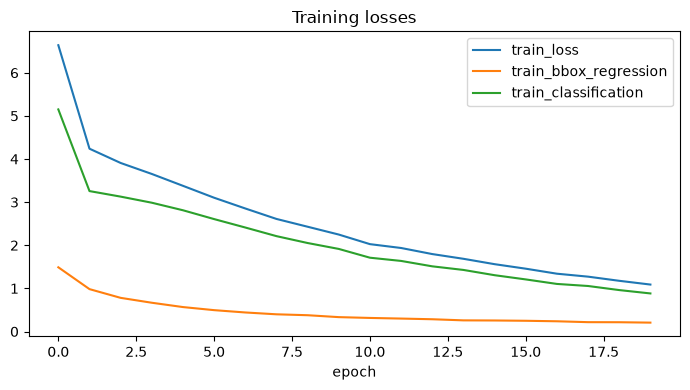

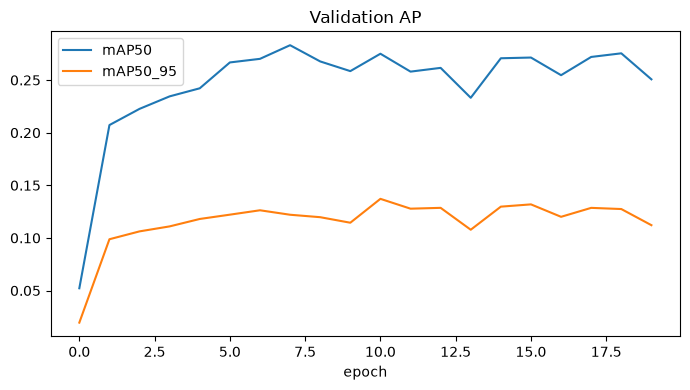

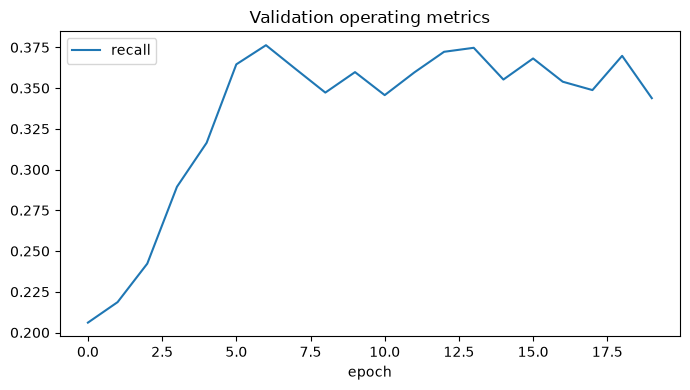

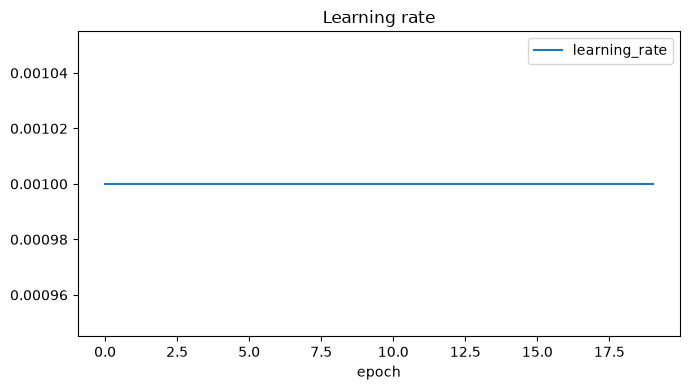

{'state': 'COMPLETED',
 'summary':   experiment_id       health  epochs best_epoch  best_mAP50_95  \
 0     E1_ssd300  INVALID_RUN      20       None        0.13715   
 
    final_mAP50_95  training_time_seconds  
 0        0.112127            2222.490044  ,
 'history':     epoch  learning_rate  training_time_seconds  train_loss  \
 0       0          0.001             148.176469    6.638450   
 1       1          0.001             148.239928    4.238687   
 2       2          0.001             149.255485    3.907814   
 3       3          0.001             130.142684    3.653083   
 4       4          0.001             107.848873    3.377924   
 5       5          0.001             102.966590    3.101751   
 6       6          0.001             102.176709    2.852589   
 7       7          0.001             101.735789    2.610133   
 8       8          0.001             101.834880    2.429354   
 9       9          0.001             101.770104    2.248037   
 10     10          0.001 

In [10]:
diagnostics = show_experiment_report("E1_ssd300")
diagnostics

**Decision:** Pending trained artifacts and common validation results. No conclusion is inferred from architecture name alone.

## E2_fcos_640 — FCOS ResNet50 FPN

**Rationale:** anchor-free alternative without anchor design. **Hypothesis:** this architecture may improve localization or minority-lesion recall relative to E0. Configuration differences are explicit in the registry. Artifacts are reused when present; otherwise status remains pending.

In [11]:
experiment=next(e for e in EXPERIMENTS if e.experiment_id=="E2_fcos_640")
display(pd.Series(inspect_artifacts(experiment),name='value').to_frame())

,value
experiment_id,E2_fcos_640
state,COMPLETED
reason,valid resumable checkpoint
run_dir,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...
best_checkpoint,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...


In [ ]:
TRAINING_MODE = "auto"
history = run_torchvision_experiment("E2_fcos_640", training_mode=TRAINING_MODE)

,experiment_id,health,epochs,best_epoch,best_mAP50_95,final_mAP50_95,training_time_seconds
0,E2_fcos_640,INVALID_RUN,20,None,0.276385,0.261525,4506.932136


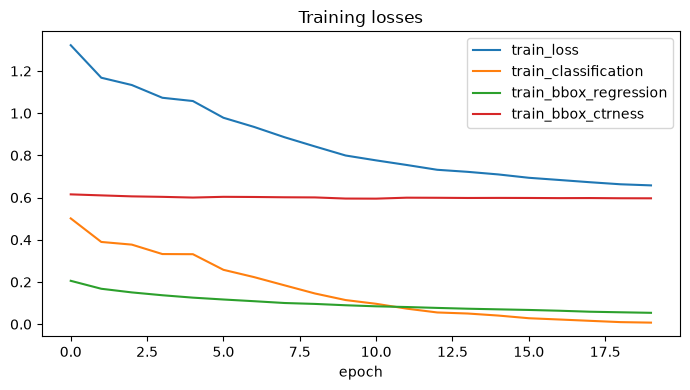

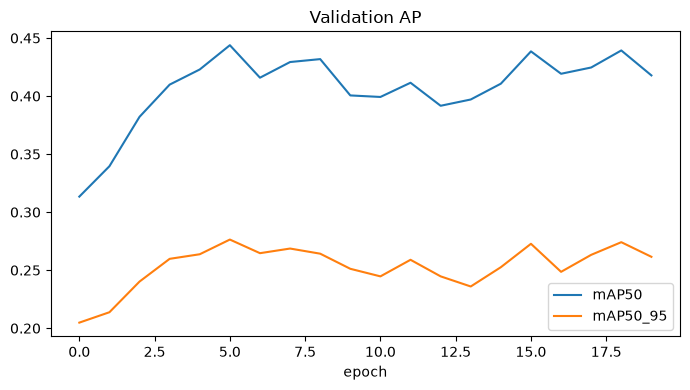

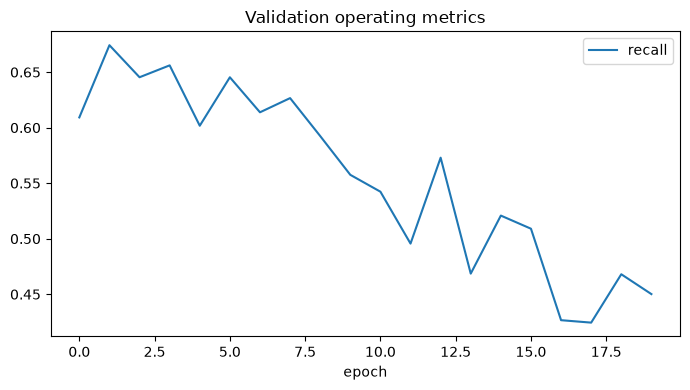

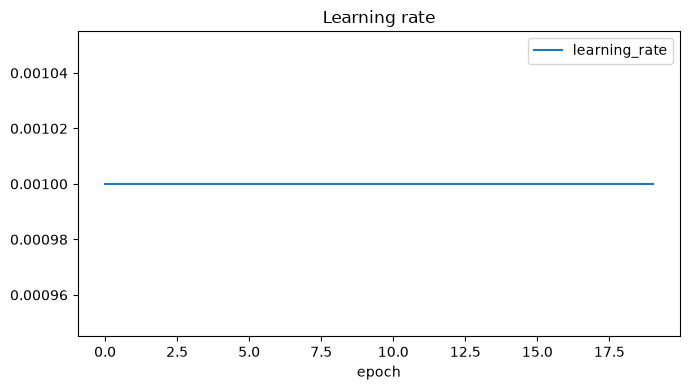

{'state': 'COMPLETED',
 'summary':   experiment_id       health  epochs best_epoch  best_mAP50_95  \
 0   E2_fcos_640  INVALID_RUN      20       None       0.276385   
 
    final_mAP50_95  training_time_seconds  
 0        0.261525            4506.932136  ,
 'history':     epoch  learning_rate  training_time_seconds  train_loss  \
 0       0          0.001             223.839110    1.322194   
 1       1          0.001             222.753171    1.168077   
 2       2          0.001             219.134621    1.133486   
 3       3          0.001             224.119132    1.073082   
 4       4          0.001             219.690018    1.057623   
 5       5          0.001             220.442422    0.978324   
 6       6          0.001             219.624416    0.935043   
 7       7          0.001             220.501089    0.886029   
 8       8          0.001             219.771566    0.842199   
 9       9          0.001             220.267910    0.799470   
 10     10          0.001 

In [12]:
diagnostics = show_experiment_report("E2_fcos_640")
diagnostics

**Decision:** Pending trained artifacts and common validation results. No conclusion is inferred from architecture name alone.

## E3_fasterrcnn_640 — Faster R-CNN ResNet50 FPN

**Rationale:** two-stage region-proposal reference. **Hypothesis:** this architecture may improve localization or minority-lesion recall relative to E0. Configuration differences are explicit in the registry. Artifacts are reused when present; otherwise status remains pending.

In [9]:
experiment=next(e for e in EXPERIMENTS if e.experiment_id=="E3_fasterrcnn_640")
display(pd.Series(inspect_artifacts(experiment),name='value').to_frame())

,value
experiment_id,E3_fasterrcnn_640
state,NOT_STARTED
reason,directory absent
run_dir,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...
best_checkpoint,NaN


In [10]:
TRAINING_MODE = "auto"
history = run_torchvision_experiment("E3_fasterrcnn_640", training_mode=TRAINING_MODE)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to C:\Users\Eclipse/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:02<00:00, 72.4MB/s] 


,check,status
0,CUDA,OK
1,torchmetrics,OK
2,sample batch,OK
3,loss finite,OK
4,checkpoint state,DIRECTORY_ONLY


E3_fasterrcnn_640 | Epoch 01/20: 100%|██████████| 247/247 [03:22<00:00,  1.22it/s, avg=0.668, bbox=0.353, cls=0.401, grad=7.40, loss=0.779, lr=2.00e-03]


----------------------------------------------------------------------
E3_fasterrcnn_640 | Epoch 01/20 completed
Train loss        : 0.6675
Recall            : 0.5169
mAP@0.5           : 0.3239
mAP@0.5:0.95      : 0.176
Learning rate     : 0.002
Mean grad norm    : 4.079
Max grad norm     : 42.17
Best mAP50-95    : 0.1760 [NEW BEST]
----------------------------------------------------------------------


...

----------------------------------------------------------------------
E3_fasterrcnn_640 | Epoch 18/20 completed
Train loss        : 0.09056
Recall            : 0.4277
mAP@0.5           : 0.4362
mAP@0.5:0.95      : 0.2657
Learning rate     : 0.002
Mean grad norm    : 2.741
Max grad norm     : 5.106
Best mAP50-95    : 0.2730
----------------------------------------------------------------------


E3_fasterrcnn_640 | Epoch 19/20: 100%|██████████| 247/247 [03:53<00:00,  1.06it/s, avg=0.086, bbox=0.030, cls=0.015, grad=2.29, loss=0.046, lr=2.00e-03]


----------------------------------------------------------------------
E3_fasterrcnn_640 | Epoch 19/20 completed
Train loss        : 0.0864
Recall            : 0.4011
mAP@0.5           : 0.4385
mAP@0.5:0.95      : 0.2614
Learning rate     : 0.002
Mean grad norm    : 2.715
Max grad norm     : 5.124
Best mAP50-95    : 0.2730
----------------------------------------------------------------------


E3_fasterrcnn_640 | Epoch 20/20: 100%|██████████| 247/247 [03:53<00:00,  1.06it/s, avg=0.082, bbox=0.006, cls=0.001, grad=0.97, loss=0.008, lr=2.00e-03]


----------------------------------------------------------------------
E3_fasterrcnn_640 | Epoch 20/20 completed
Train loss        : 0.0815
Recall            : 0.3804
mAP@0.5           : 0.4111
mAP@0.5:0.95      : 0.2455
Learning rate     : 0.002
Mean grad norm    : 2.623
Max grad norm     : 5.548
Best mAP50-95    : 0.2730
----------------------------------------------------------------------


,experiment_id,health,epochs,best_epoch,best_mAP50_95,final_mAP50_95,training_time_seconds
0,E3_fasterrcnn_640,INVALID_RUN,20,None,0.272988,0.245476,5091.598721


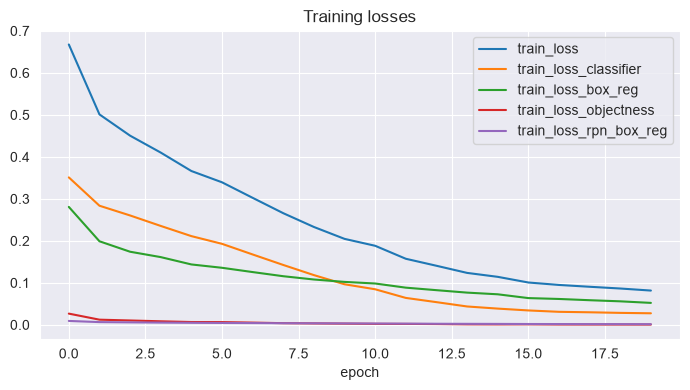

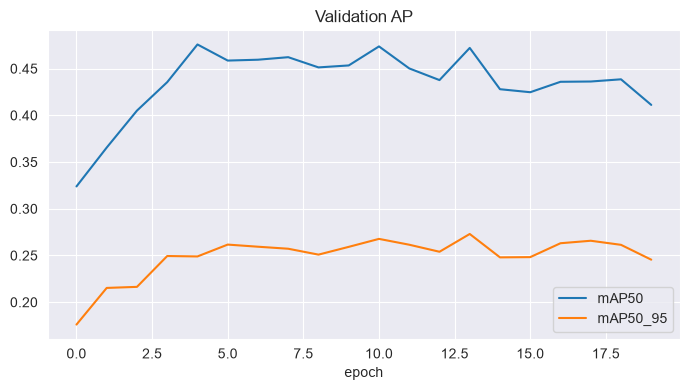

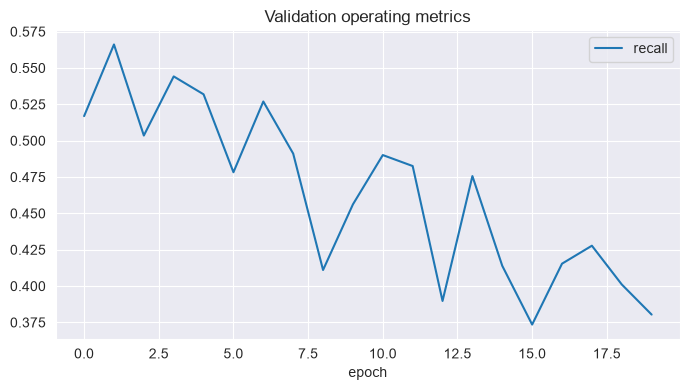

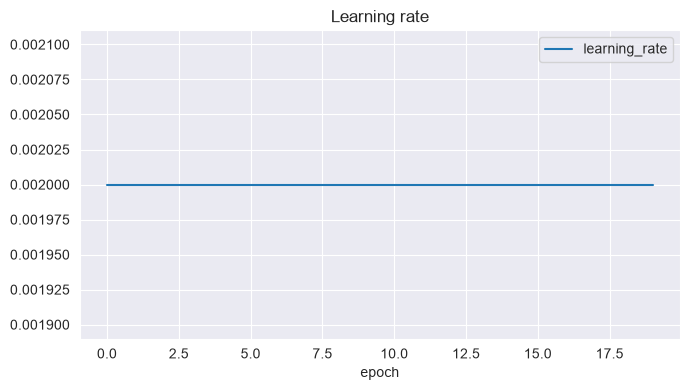

{'state': 'COMPLETED',
 'summary':        experiment_id       health  epochs best_epoch  best_mAP50_95  \
 0  E3_fasterrcnn_640  INVALID_RUN      20       None       0.272988   
 
    final_mAP50_95  training_time_seconds  
 0        0.245476            5091.598721  ,
 'history':     epoch  learning_rate  training_time_seconds  train_loss  \
 0       0          0.002             227.193303    0.667548   
 1       1          0.002             234.725822    0.500979   
 2       2          0.002             244.822224    0.450370   
 3       3          0.002             250.261250    0.410099   
 4       4          0.002             254.958967    0.366189   
 5       5          0.002             256.411826    0.339329   
 6       6          0.002             258.796631    0.302348   
 7       7          0.002             258.100956    0.265739   
 8       8          0.002             259.029229    0.232931   
 9       9          0.002             256.407460    0.204612   
 10     10      

In [11]:
diagnostics = show_experiment_report("E3_fasterrcnn_640")
diagnostics

**Decision:** Pending trained artifacts and common validation results. No conclusion is inferred from architecture name alone.

## DETR-specific training, validation, and persistence utilities

In [23]:
DETR_MODEL_NAME = "facebook/detr-resnet-50"
DETR_BACKBONE_LR = 1e-5
DETR_ID2LABEL = {
    0: "Impacted",
    1: "Caries",
    2: "Periapical Lesion",
    3: "Deep Caries",
}
DETR_LABEL2ID = {name: class_id for class_id, name in DETR_ID2LABEL.items()}

def require_detr_dependencies() -> None:
    if not TRANSFORMERS_AVAILABLE or AutoImageProcessor is None or DetrConfig is None or DetrForObjectDetection is None:
        raise RuntimeError("DETR requires the transformers package. Install it before manually running E4.")
    if not TORCHMETRICS_AVAILABLE or MeanAveragePrecision is None:
        raise RuntimeError("DETR validation requires torchmetrics[detection] and pycocotools.")

def build_detr_model() -> tuple[nn.Module, object, dict[str, object]]:
    require_detr_dependencies()
    import transformers
    processor = AutoImageProcessor.from_pretrained(DETR_MODEL_NAME)
    config = DetrConfig.from_pretrained(DETR_MODEL_NAME)
    config.id2label = dict(DETR_ID2LABEL)
    config.label2id = dict(DETR_LABEL2ID)
    config.num_labels = len(DETR_ID2LABEL)
    model = DetrForObjectDetection.from_pretrained(
        DETR_MODEL_NAME,
        config=config,
        ignore_mismatched_sizes=True,
    )
    normalized_id2label = {int(key): value for key, value in model.config.id2label.items()}
    assert model.config.num_labels == 4
    assert normalized_id2label == DETR_ID2LABEL
    assert model.config.label2id == DETR_LABEL2ID
    print("DETR initialization")
    print(f"model            : {DETR_MODEL_NAME}")
    print(f"num_labels       : {model.config.num_labels}")
    print(f"classes          : {', '.join(DETR_ID2LABEL.values())}")
    print("classifier head  : reinitialized from COCO")
    print(f"device           : {next(model.parameters()).device}")
    metadata = {'pretrained_model':DETR_MODEL_NAME,'num_labels':4,'class_mapping':DETR_ID2LABEL,'transformers_version':transformers.__version__,'input_policy':'AutoImageProcessor resize/normalize; processor.pad per batch','training_protocol':'detr_screening_fixed_lr_v1','backbone_learning_rate':DETR_BACKBONE_LR}
    return model, processor, metadata

def build_detr_loaders(experiment: Experiment, processor) -> tuple[DataLoader, DataLoader]:
    train_data = DentexDetrDataset(TRAIN_JSON, TRAIN_IMAGES, processor)
    validation_data = DentexDetrDataset(VAL_JSON, VAL_IMAGES, processor)
    def collate(items):
        pixel_values = [item['pixel_values'] for item in items]
        padded_height = max(image.shape[-2] for image in pixel_values)
        padded_width = max(image.shape[-1] for image in pixel_values)
        padded_size = (padded_height, padded_width)

        padded_images = []
        pixel_masks = []
        for image in pixel_values:
            padded_image, pixel_mask, _ = processor.pad(
                image=image,
                padded_size=padded_size,
            )
            padded_images.append(padded_image)
            pixel_masks.append(pixel_mask)

        return {
            'pixel_values': torch.stack(padded_images),
            'pixel_mask': torch.stack(pixel_masks),
            'labels': [item['labels'] for item in items],
            'target_boxes': [item['target_boxes'] for item in items],
            'target_labels': [item['target_labels'] for item in items],
            'original_sizes': [item['original_size'] for item in items],
            'image_ids': [item['image_id'] for item in items],
        }
    train_loader = DataLoader(train_data,batch_size=experiment.batch_size,shuffle=True,collate_fn=collate,num_workers=0,pin_memory=True)
    validation_loader = DataLoader(validation_data,batch_size=experiment.batch_size,shuffle=False,collate_fn=collate,num_workers=0,pin_memory=True)
    return train_loader, validation_loader

def create_detr_optimizer(experiment: Experiment, model: nn.Module):
    backbone = []
    main = []
    for name, parameter in model.named_parameters():
        (backbone if 'backbone' in name else main).append(parameter)
    return torch.optim.AdamW([{'params':main,'lr':experiment.learning_rate},{'params':backbone,'lr':DETR_BACKBONE_LR}],weight_decay=experiment.weight_decay)

def move_detr_labels(labels: list[dict[str,torch.Tensor]], device: torch.device) -> list[dict[str,torch.Tensor]]:
    return [{key:value.to(device) for key,value in label.items()} for label in labels]

def detr_model_is_finite(model: nn.Module) -> bool:
    return all(not torch.is_floating_point(value) or bool(torch.isfinite(value).all()) for value in model.state_dict().values())

def inspect_detr_state(experiment: Experiment) -> dict[str, object]:
    run_dir=PATHS.experiments/experiment.artifact_name; last_dir=run_dir/'last'; best_dir=run_dir/'best'; state_path=run_dir/'training_state.pt'; history_path=run_dir/'history.csv'; metrics_path=run_dir/'metrics.json'
    if not run_dir.exists(): status='NOT_STARTED'; reason='run directory absent'; state=None
    elif not any(item.is_file() for item in run_dir.rglob('*')): status='DIRECTORY_ONLY'; reason='run directory empty'; state=None
    elif not state_path.is_file() or not (last_dir/'config.json').is_file(): status='INCOMPLETE_NON_RESUMABLE'; reason='missing last model or training_state.pt'; state=None
    else:
        try: state=torch.load(state_path,map_location='cpu',weights_only=False)
        except Exception as error: return {'state':'INCOMPLETE_NON_RESUMABLE','reason':str(error),'run_dir':run_dir}
        expected={'experiment_id':experiment.experiment_id,'model_family':'detr','training_protocol':'detr_screening_fixed_lr_v1','pretrained_model':DETR_MODEL_NAME,'learning_rate':experiment.learning_rate,'backbone_learning_rate':DETR_BACKBONE_LR,'weight_decay':experiment.weight_decay,'gradient_clip_norm':experiment.gradient_clip_norm,'batch_size':experiment.batch_size,'class_mapping':CANONICAL_CLASS_NAMES}
        compatible=all(state.get(key)==value for key,value in expected.items()) and 'optimizer_state_dict' in state and isinstance(state.get('epoch'),int)
        finite=not state.get('nonfinite_model',False)
        if not finite: status='INVALID_NUMERICAL_CHECKPOINT'; reason='saved DETR state is marked non-finite'
        elif not compatible: status='INCOMPATIBLE_CONFIGURATION'; reason='training-state metadata differs from E4 protocol'
        elif state['epoch']+1>=experiment.epochs and best_dir.is_dir() and history_path.is_file(): status='COMPLETED'; reason='configured epoch budget completed'
        else: status='INTERRUPTED_RESUMABLE'; reason='valid last model and optimizer state'
    return {'state':status,'reason':reason,'run_dir':run_dir,'last_dir':last_dir,'best_dir':best_dir,'state_path':state_path,'history_path':history_path,'metrics_path':metrics_path,'training_state':state}

def detr_preflight(experiment,model,processor,train_loader,val_loader,device):
    checks=[('transformers','OK'),('CUDA','OK'),('train dataset',str(len(train_loader.dataset))),('val dataset',str(len(val_loader.dataset)))]
    batch=next(iter(train_loader)); pixels=batch['pixel_values'].to(device); mask=batch['pixel_mask'].to(device) if batch['pixel_mask'] is not None else None; labels=move_detr_labels(batch['labels'],device)
    if not torch.isfinite(pixels).all(): raise RuntimeError('DETR preflight found non-finite pixels.')
    model.train(); model.zero_grad(set_to_none=True); output=model(pixel_values=pixels,pixel_mask=mask,labels=labels)
    if not torch.isfinite(output.loss) or any(not torch.isfinite(value) for value in output.loss_dict.values()): raise RuntimeError('DETR preflight found non-finite loss.')
    output.loss.backward(); gradient=torch.nn.utils.clip_grad_norm_(model.parameters(),experiment.gradient_clip_norm)
    if not torch.isfinite(gradient): raise RuntimeError('DETR preflight found non-finite gradients.')
    model.zero_grad(set_to_none=True); checks.extend([('sample batch','OK'),('forward','OK'),('loss finite','OK'),('gradient finite','OK'),('checkpoint state',inspect_detr_state(experiment)['state'])]); return pd.DataFrame(checks,columns=['check','status'])

def train_one_detr_epoch(experiment,model,loader,optimizer,device,epoch):
    model.train(); totals={}; gradients=[]; progress=tqdm(loader,desc=f'{experiment.experiment_id} | Epoch {epoch+1:02d}/{experiment.epochs}')
    for batch_index,batch in enumerate(progress):
        pixels=batch['pixel_values'].to(device); mask=batch['pixel_mask'].to(device) if batch['pixel_mask'] is not None else None; labels=move_detr_labels(batch['labels'],device); optimizer.zero_grad(set_to_none=True); output=model(pixel_values=pixels,pixel_mask=mask,labels=labels)
        components={name:value for name,value in output.loss_dict.items()}
        if not torch.isfinite(output.loss) or any(not torch.isfinite(value) for value in components.values()): raise RuntimeError(f'Numerical instability | experiment={experiment.experiment_id} epoch={epoch+1} batch={batch_index+1} loss={float(output.loss)} components={ {k:float(v) for k,v in components.items()} } lrs={[g["lr"] for g in optimizer.param_groups]}')
        output.loss.backward(); gradient=torch.nn.utils.clip_grad_norm_(model.parameters(),experiment.gradient_clip_norm)
        if not torch.isfinite(gradient): raise RuntimeError(f'Non-finite DETR gradient | experiment={experiment.experiment_id} epoch={epoch+1} batch={batch_index+1}')
        optimizer.step()
        if batch_index%10==0 and not detr_model_is_finite(model): raise RuntimeError(f'Non-finite DETR parameters | epoch={epoch+1} batch={batch_index+1}')
        values={'train_loss':float(output.loss.detach()),**{f'train_{key}':float(value.detach()) for key,value in components.items()}}
        for key,value in values.items(): totals[key]=totals.get(key,0.0)+value
        gradients.append(float(gradient)); postfix={'loss':f'{values["train_loss"]:.3f}','avg':f'{totals["train_loss"]/(batch_index+1):.3f}','lr':f'{optimizer.param_groups[0]["lr"]:.1e}','grad':f'{float(gradient):.2f}'}
        for key in ('loss_ce','loss_bbox','loss_giou'):
            if f'train_{key}' in values: postfix[key.replace('loss_','')]=f'{values[f"train_{key}"]:.3f}'
        progress.set_postfix(postfix)
    return {key:value/len(loader) for key,value in totals.items()}|{'mean_gradient_norm':float(np.mean(gradients)),'max_gradient_norm':float(np.max(gradients))}

def evaluate_detr(model,processor,loader,device):
    metric=MeanAveragePrecision(box_format='xyxy',iou_type='bbox',class_metrics=True); model.eval()
    with torch.inference_mode():
        for batch in loader:
            pixels=batch['pixel_values'].to(device); mask=batch['pixel_mask'].to(device) if batch['pixel_mask'] is not None else None; output=model(pixel_values=pixels,pixel_mask=mask); sizes=torch.tensor(batch['original_sizes'],device=device); processed=processor.post_process_object_detection(output,target_sizes=sizes,threshold=0.0)
            predictions=[{key:value.detach().cpu() for key,value in item.items()} for item in processed]
            targets=[{'boxes':boxes,'labels':labels} for boxes,labels in zip(batch['target_boxes'],batch['target_labels'])]; metric.update(predictions,targets)
    result=metric.compute(); per_class={CANONICAL_CLASS_NAMES[int(label)]:{'AP50_95':float(result['map_per_class'][index]),'recall':float(result['mar_100_per_class'][index])} for index,label in enumerate(result['classes'].tolist())}
    return {'recall':float(result['mar_100']),'mAP50':float(result['map_50']),'mAP50_95':float(result['map']),'per_class':per_class}

def save_detr_state(model,processor,optimizer,experiment,state,epoch,best,history,run_id,directory):
    if not detr_model_is_finite(model): raise RuntimeError('Refusing to save non-finite DETR model.')
    directory.mkdir(parents=True,exist_ok=True); model.save_pretrained(directory); processor.save_pretrained(directory)
    payload={'optimizer_state_dict':optimizer.state_dict(),'epoch':epoch,'history':history,'best_metric':best,'mlflow_run_id':run_id,'experiment_id':experiment.experiment_id,'model_family':'detr','training_protocol':'detr_screening_fixed_lr_v1','pretrained_model':DETR_MODEL_NAME,'learning_rate':experiment.learning_rate,'backbone_learning_rate':DETR_BACKBONE_LR,'weight_decay':experiment.weight_decay,'gradient_clip_norm':experiment.gradient_clip_norm,'batch_size':experiment.batch_size,'class_mapping':CANONICAL_CLASS_NAMES,'nonfinite_model':False}
    torch.save(payload,state['state_path']); torch.save(optimizer.state_dict(),state['run_dir']/'optimizer.pt')

def serialize_detr_mlflow_params(values: dict[str, object]) -> dict[str, str | int | float | bool]:
    serialized = {}
    for key, value in values.items():
        if isinstance(value, (str, int, float, bool)):
            serialized[key] = value
        elif value is None:
            serialized[key] = "None"
        elif isinstance(value, (dict, list, tuple)):
            serialized[key] = json.dumps(value, sort_keys=True)
        else:
            serialized[key] = str(value)
    return serialized

def run_detr_experiment(experiment_id: str, training_mode: str = "auto") -> pd.DataFrame:
    experiment = get_experiment(experiment_id)
    require_detr_dependencies()
    device = require_training_device()
    print("[DETR] Preparing run state...")
    state = inspect_detr_state(experiment)
    if training_mode not in {"auto", "new", "resume"}: raise ValueError(training_mode)
    if state["state"] == "COMPLETED": return pd.read_csv(state["history_path"])
    if state["state"] in {"INVALID_NUMERICAL_CHECKPOINT", "INCOMPATIBLE_CONFIGURATION", "INCOMPLETE_NON_RESUMABLE"}: raise RuntimeError(f'DETR {state["state"]}: {state["reason"]}')
    if training_mode == "resume" and state["state"] != "INTERRUPTED_RESUMABLE": raise RuntimeError(f'DETR resume unavailable: {state["state"]}')
    if training_mode == "new" and state["state"] not in {"NOT_STARTED", "DIRECTORY_ONLY"}: raise RuntimeError("DETR new mode will not overwrite artifacts.")

    model, processor, metadata = build_detr_model()
    train_loader, val_loader = build_detr_loaders(experiment, processor)
    model.to(device)
    history, start, best, run_id = [], 0, -float("inf"), None
    saved = state.get("training_state")
    if state["state"] == "INTERRUPTED_RESUMABLE":
        model = DetrForObjectDetection.from_pretrained(state["last_dir"]).to(device)
        history = list(saved["history"])
        start = saved["epoch"] + 1
        best = float(saved["best_metric"])
        run_id = saved.get("mlflow_run_id")

    display(detr_preflight(experiment, model, processor, train_loader, val_loader, device))
    print("[DETR] Preflight complete")
    print("[DETR] Preparing optimizer...")
    optimizer = create_detr_optimizer(experiment, model)
    if saved is not None:
        optimizer.load_state_dict(saved["optimizer_state_dict"])
    print("[DETR] Optimizer ready")
    state["run_dir"].mkdir(parents=True, exist_ok=True)

    print("[DETR] Initializing MLflow run...")
    run_context = mlflow.start_run(run_id=run_id) if run_id else mlflow.start_run(run_name=experiment.experiment_id)
    with run_context as run:
        print("[DETR] MLflow run ready")
        mlflow.set_tags({'experiment_id':experiment.experiment_id,'model_family':'detr','training_protocol':'detr_screening_fixed_lr_v1'})
        print("[DETR] Logging parameters...")
        parameters = serialize_detr_mlflow_params({**asdict(experiment),'backbone_learning_rate':DETR_BACKBONE_LR,'pretrained_model':DETR_MODEL_NAME,'class_mapping':DETR_ID2LABEL})
        mlflow.log_params(parameters)
        print("[DETR] Parameters logged")
        for epoch in range(start, experiment.epochs):
            print(f"[DETR] Starting epoch {epoch + 1}/{experiment.epochs}")
            started = time.perf_counter()
            train_metrics = train_one_detr_epoch(experiment, model, train_loader, optimizer, device, epoch)
            validation = evaluate_detr(model, processor, val_loader, device)
            row = {'epoch':epoch,'learning_rate':experiment.learning_rate,'backbone_learning_rate':DETR_BACKBONE_LR,'training_time_seconds':time.perf_counter()-started,**train_metrics,**{key:value for key,value in validation.items() if key!='per_class'}}
            history.append(row)
            improved = row['mAP50_95'] > best
            best = max(best, row['mAP50_95'])
            save_detr_state(model,processor,optimizer,experiment,state,epoch,best,history,run.info.run_id,state['last_dir'])
            if improved: save_detr_state(model,processor,optimizer,experiment,state,epoch,best,history,run.info.run_id,state['best_dir'])
            pd.DataFrame(history).to_csv(state['history_path'],index=False)
            state['metrics_path'].write_text(json.dumps({'experiment_id':experiment.experiment_id,'training_protocol':'detr_screening_fixed_lr_v1','best_epoch':int(pd.DataFrame(history).mAP50_95.idxmax()),'best_mAP50_95':best,'per_class':validation['per_class']},indent=2),encoding='utf-8')
            mlflow.log_metrics({key:value for key,value in row.items() if key!='epoch'},step=epoch)
    return pd.DataFrame(history)

def show_detr_experiment_report(experiment_id: str):
    experiment=get_experiment(experiment_id); state=inspect_detr_state(experiment)
    if not state.get('history_path') or not state['history_path'].is_file(): print(f'DETR state: {state["state"]}'); return pd.DataFrame()
    history=pd.read_csv(state['history_path']); invalid=history.empty or not np.isfinite(history['train_loss']).all() or (history['mAP50_95']==0).all(); health='INVALID_RUN' if invalid else 'STILL_IMPROVING' if history['mAP50_95'].tail(5).diff().mean()>0.001 else 'POTENTIAL_OVERFITTING' if history['train_loss'].tail(5).diff().mean()<0 and history['mAP50_95'].iloc[-1]<history['mAP50_95'].max()-0.02 else 'COMPLETED_STABLE'
    summary=pd.DataFrame([{'state':state['state'],'health':health,'epochs':len(history),'best_epoch':int(history.mAP50_95.idxmax()+1),'best_mAP50_95':history.mAP50_95.max(),'final_mAP50_95':history.mAP50_95.iloc[-1],'best_mAP50':history.mAP50.max(),'recall':history.recall.iloc[-1],'training_time_seconds':history.training_time_seconds.sum(),'best_model':str(state['best_dir'])}]); display(summary)
    for columns,title in [(['train_loss','train_loss_ce','train_loss_bbox','train_loss_giou'],'DETR losses'),(['mAP50','mAP50_95','recall'],'Validation metrics'),(['mean_gradient_norm','max_gradient_norm'],'Gradient norms'),(['learning_rate','backbone_learning_rate'],'Fixed learning rates')]:
        available=[column for column in columns if column in history]
        if available: ax=history.plot(x='epoch',y=available,title=title,figsize=(7,4)); ax.axvline(history.mAP50_95.idxmax(),ls='--',color='black'); plt.tight_layout(); plt.show()
    return summary

def show_detr_validation_predictions(experiment_id: str,num_images: int=3,confidence_threshold: float=0.3):
    experiment=get_experiment(experiment_id); state=inspect_detr_state(experiment)
    if state['state']!='COMPLETED': print(f'DETR predictions unavailable: {state["state"]}'); return
    require_detr_dependencies()
    from PIL import ImageDraw
    processor=AutoImageProcessor.from_pretrained(state['best_dir']); model=DetrForObjectDetection.from_pretrained(state['best_dir']).to(DEVICE).eval(); dataset=DentexDetrDataset(VAL_JSON,VAL_IMAGES,processor)
    for index in np.linspace(0,len(dataset)-1,num_images,dtype=int):
        item=dataset[index]; image=Image.open(VAL_IMAGES/item['file_name']).convert('RGB'); inputs=processor(images=image,return_tensors='pt').to(DEVICE)
        with torch.inference_mode(): output=model(**inputs)
        prediction=processor.post_process_object_detection(output,target_sizes=torch.tensor([item['original_size']],device=DEVICE),threshold=confidence_threshold)[0]; draw=ImageDraw.Draw(image)
        for box,label in zip(item['target_boxes'].tolist(),item['target_labels'].tolist()): draw.rectangle(box,outline='lime',width=3); draw.text((box[0],box[1]),f'GT {CANONICAL_CLASS_NAMES[label]}',fill='lime')
        for box,label,score in zip(prediction['boxes'].cpu().tolist(),prediction['labels'].cpu().tolist(),prediction['scores'].cpu().tolist()): draw.rectangle(box,outline='red',width=3); draw.text((box[0],box[1]),f'{CANONICAL_CLASS_NAMES[label]} {score:.2f}',fill='red')
        display(image); print(f'GT: {len(item["target_boxes"])} | predictions: {len(prediction["boxes"])}')


## E4_detr_640 — DETR ResNet50

**Rationale:** transformer detector with global attention and object queries. **Hypothesis:** this architecture may improve localization or minority-lesion recall relative to E0. Configuration differences are explicit in the registry. Artifacts are reused when present; otherwise status remains pending.

In [24]:
experiment = get_experiment("E4_detr_640")
display(pd.Series(inspect_detr_state(experiment), name="value").drop(labels=["training_state"], errors="ignore").to_frame())

,value
state,INTERRUPTED_RESUMABLE
reason,valid last model and optimizer state
run_dir,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...
last_dir,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...
best_dir,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...
state_path,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...
history_path,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...
metrics_path,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...


In [25]:
TRAINING_MODE = "auto"
history = run_detr_experiment("E4_detr_640", training_mode=TRAINING_MODE)

[DETR] Preparing run state...


Loading weights: 100%|██████████| 530/530 [00:00<00:00, 2667.84it/s]
[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |                                                                                        
---------------------------------------------------------------+------------+----------------------------------------------------------------------------------------
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.

DETR initialization
model            : facebook/detr-resnet-50
num_labels       : 4
classes          : Impacted, Caries, Periapical Lesion, Deep Caries
classifier head  : reinitialized from COCO
device           : cpu


Loading weights: 100%|██████████| 530/530 [00:00<00:00, 2941.09it/s]


,check,status
0,transformers,OK
1,CUDA,OK
2,train dataset,493
3,val dataset,106
4,sample batch,OK
5,forward,OK
6,loss finite,OK
7,gradient finite,OK
8,checkpoint state,INTERRUPTED_RESUMABLE


...

E4_detr_640 | Epoch 18/20: 100%|██████████| 247/247 [04:45<00:00,  1.16s/it, loss=0.989, avg=1.219, lr=1.0e-04, grad=145.78, ce=0.583, bbox=0.019, giou=0.156] 
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.53it/s]


[DETR] Starting epoch 19/20


E4_detr_640 | Epoch 19/20: 100%|██████████| 247/247 [04:48<00:00,  1.17s/it, loss=0.734, avg=1.132, lr=1.0e-04, grad=66.58, ce=0.365, bbox=0.021, giou=0.132] 
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.57it/s]


[DETR] Starting epoch 20/20


E4_detr_640 | Epoch 20/20: 100%|██████████| 247/247 [04:47<00:00,  1.16s/it, loss=0.778, avg=1.156, lr=1.0e-04, grad=175.93, ce=0.314, bbox=0.015, giou=0.195]
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  6.15it/s]


In [12]:
diagnostics = show_detr_experiment_report("E4_detr_640")
diagnostics

NameError: name 'show_detr_experiment_report' is not defined

In [18]:
show_detr_validation_predictions("E4_detr_640", num_images=3)

DETR predictions unavailable: INTERRUPTED_RESUMABLE


**Decision:** Pending trained artifacts and common validation results. No conclusion is inferred from architecture name alone.

## 13. Architecture screening and MLflow leaderboard

In [19]:
def mlflow_leaderboard() -> pd.DataFrame:
    exp=mlflow.get_experiment_by_name(MLFLOW_EXPERIMENT)
    if exp is None:
        return pd.DataFrame(columns=['experiment_id','model_name','architecture','imgsz','precision','recall','mAP50','mAP50_95'])
    runs=mlflow.search_runs([exp.experiment_id],order_by=['metrics.mAP50_95 DESC'])
    columns={'tags.experiment_id':'experiment_id','params.model_name':'model_name','params.architecture':'architecture','params.image_size':'imgsz','metrics.precision':'precision','metrics.recall':'recall','metrics.mAP50':'mAP50','metrics.mAP50_95':'mAP50_95','metrics.best_epoch':'best_epoch','metrics.inference_latency_ms':'inference_latency_ms','metrics.peak_gpu_memory_mb':'peak_gpu_memory_mb'}
    return runs[[c for c in columns if c in runs]].rename(columns=columns)

leaderboard=mlflow_leaderboard(); display(leaderboard)
if len(leaderboard)==1: print('[SCREENING] Only E0 is complete; architecture selection remains provisional.')

,experiment_id,model_name,architecture,imgsz,precision,recall,mAP50,mAP50_95,best_epoch
0,E0_yolo26n_640_baseline,YOLO26n,one-stage,640,0.445384,0.478697,0.431174,0.264111,18.0
1,NaN,NaN,NaN,NaN,NaN,0.450136,0.417811,0.261525,NaN
2,NaN,NaN,NaN,NaN,NaN,0.284047,0.242171,0.114087,NaN
3,NaN,NaN,NaN,NaN,NaN,0.343819,0.250718,0.112127,NaN
4,E4_detr_640,DETR ResNet50,transformer,640,NaN,0.211879,0.180245,0.082644,NaN
5,E1_ssd300,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN
6,E1_ssd300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,E1_ssd300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 14. Controlled refinement plan

In [20]:
REFINEMENT_PLAN=pd.DataFrame([
 {'experiment_id':'R1_selected_1024','factor':'resolution','value':'1024','control':'selected architecture at 640','hypothesis':'improve recall for boxes below 1% image area'},
 {'experiment_id':'H1_selected_cosine_lr001','factor':'scheduler','value':'cosine, lr=0.001','control':'same selected model/configuration','hypothesis':'smoother convergence than framework default'},
 {'experiment_id':'H2_selected_cosine_lr0005','factor':'learning_rate','value':'cosine, lr=0.0005','control':'H1 except learning rate','hypothesis':'reduce late-epoch instability'},
 {'experiment_id':'A1_selected_domain_safe','factor':'augmentation','value':'mild rotation/translation/scale/intensity','control':'baseline conservative augmentation','hypothesis':'improve robustness without anatomical distortion'},
])
display(REFINEMENT_PLAN)

,experiment_id,factor,value,control,hypothesis
0,R1_selected_1024,resolution,1024,selected architecture at 640,improve recall for boxes below 1% image area
1,H1_selected_cosine_lr001,scheduler,"cosine, lr=0.001",same selected model/configuration,smoother convergence than framework default
2,H2_selected_cosine_lr0005,learning_rate,"cosine, lr=0.0005",H1 except learning rate,reduce late-epoch instability
3,A1_selected_domain_safe,augmentation,mild rotation/translation/scale/intensity,baseline conservative augmentation,improve robustness without anatomical distortion


Scheduler tuning occurs only after architecture screening. Each run records epoch-level learning rate alongside train/validation loss and validation mAP. YOLO E0 used `cos_lr=False`, making cosine scheduling a controlled change. ReduceLROnPlateau is considered only for loops with a reliable validation-loss signal. No Cartesian sweep is launched.

In [ ]:
# MANUAL EXECUTION — CONTROLLED REFINEMENT
# Set exactly one approved refinement ID, keep all other factors fixed, then use the selected architecture's trainer.
REFINEMENT_TO_RUN=None
if REFINEMENT_TO_RUN is None:
    print('[REFINEMENT] No refinement selected. Manual execution only.')
elif REFINEMENT_TO_RUN not in set(REFINEMENT_PLAN.experiment_id):
    raise ValueError(f'Unknown refinement: {REFINEMENT_TO_RUN}')
# The trainer must create a unique artifacts/experiments/<id> directory, checkpoint best/latest state,
# and log parameters, per-epoch LR/loss/mAP, final metrics, diagnostics, and artifact paths to one MLflow run.

## 15. Training dynamics and comparative plots

,experiment_id,model,architecture,imgsz,precision,recall,mAP50,mAP50_95,best_epoch,training_time_seconds,inference_latency_ms,parameter_count,model_size_mb,small_object_recall
0,E0_yolo26n_640_baseline,YOLO26n,one-stage,640,0.445384,0.478697,0.431174,0.264111,18,None,None,None,None,None
1,E4_detr_640,DETR ResNet50,transformer,640,NaN,NaN,NaN,NaN,1,None,None,None,None,None


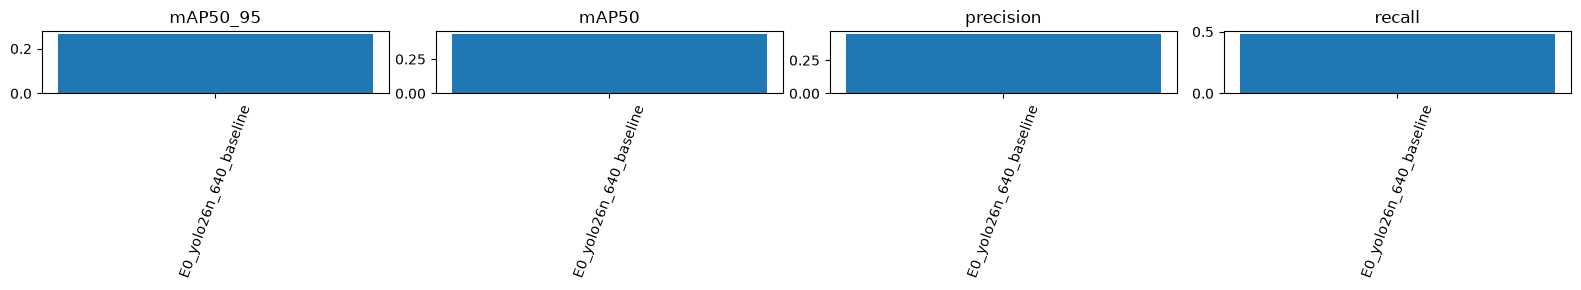

In [21]:
def load_completed_summaries():
    rows=[]
    for exp in EXPERIMENTS:
        run_dir=PATHS.baseline if exp.experiment_id.startswith('E0_') else PATHS.experiments/exp.artifact_name
        metric_path=baseline_metrics_path if exp.experiment_id.startswith('E0_') else run_dir/'metrics.json'
        if metric_path.is_file() and (exp.experiment_id.startswith('E0_') or json.loads(metric_path.read_text(encoding='utf-8')).get('training_protocol') == exp.training_protocol):
            m=json.loads(metric_path.read_text(encoding='utf-8')); rows.append({'experiment_id':exp.experiment_id,'model':exp.model_name,'architecture':exp.architecture,'imgsz':exp.image_size,'precision':m.get('precision'),'recall':m.get('recall'),'mAP50':m.get('mAP50',m.get('mAP@0.5')),'mAP50_95':m.get('mAP50_95',m.get('mAP@0.5:0.95')),'best_epoch':m.get('best_epoch'),'training_time_seconds':m.get('training_time_seconds'),'inference_latency_ms':m.get('inference_latency_ms'),'parameter_count':m.get('parameter_count'),'model_size_mb':m.get('model_size_mb'),'small_object_recall':m.get('small_object_recall')})
    return pd.DataFrame(rows)

def plot_comparisons(summary):
    metrics=['mAP50_95','mAP50','precision','recall','small_object_recall']; available=[m for m in metrics if m in summary and summary[m].notna().any()]
    if not available: return
    fig,axes=plt.subplots(1,len(available),figsize=(4*len(available),3)); axes=np.atleast_1d(axes)
    for ax,metric in zip(axes,available): ax.bar(summary.experiment_id,summary[metric]); ax.set_title(metric); ax.tick_params(axis='x',rotation=70)
    plt.tight_layout(); plt.show()

summary=load_completed_summaries().sort_values('mAP50_95',ascending=False); summary.to_csv(PATHS.modeling/'experiment_summary.csv',index=False)
display(summary); plot_comparisons(summary)

## 16. Per-class and small-object comparison

,experiment_id,class_name,precision,recall,AP50,AP50_95
32,E0_yolo26n_640_baseline,Impacted,0.730840,0.929293,0.912854,0.560375
33,E0_yolo26n_640_baseline,Caries,0.372364,0.492958,0.373898,0.253688
34,E0_yolo26n_640_baseline,Periapical Lesion,0.313893,0.080617,0.081095,0.043517
35,E0_yolo26n_640_baseline,Deep Caries,0.364439,0.411920,0.356851,0.198866


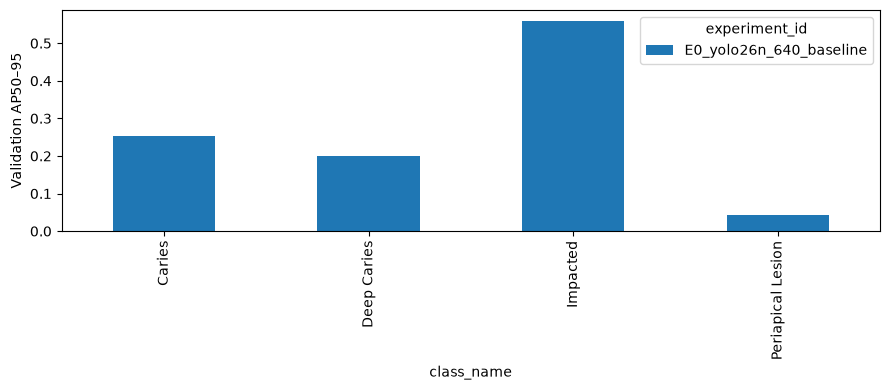

Approximate size bins: [('very_small', 0.0, 0.005), ('small', 0.005, 0.01), ('medium', 0.01, 0.02), ('large', 0.02, inf)]


In [22]:
def per_class_from_mlflow():
    exp=mlflow.get_experiment_by_name(MLFLOW_EXPERIMENT); runs=mlflow.search_runs([exp.experiment_id]); rows=[]
    for _,run in runs.iterrows():
        for class_name in CLASS_NAMES.values():
            slug=class_name.lower().replace(' ','_'); prefix='metrics.'+slug
            rows.append({'experiment_id':run.get('tags.experiment_id'),'class_name':class_name,'precision':run.get(prefix+'_precision'),'recall':run.get(prefix+'_recall'),'AP50':run.get(prefix+'_AP50'),'AP50_95':run.get(prefix+'_AP50_95')})
    return pd.DataFrame(rows).dropna(subset=['AP50_95'],how='all')

per_class_comparison=per_class_from_mlflow(); display(per_class_comparison)
if not per_class_comparison.empty:
    pivot=per_class_comparison.pivot(index='class_name',columns='experiment_id',values='AP50_95'); pivot.plot.bar(figsize=(9,4)); plt.ylabel('Validation AP50–95'); plt.tight_layout(); plt.show()
print('Approximate size bins:',SIZE_BINS)

## 17. Qualitative comparison protocol

In [23]:
def deterministic_validation_cases(dataset: DentexCocoDataset, limit: int = 6) -> pd.DataFrame:
    records = []
    for info in dataset.images:
        annotations = dataset.annotations_by_image.get(info['id'], [])
        ratios = [annotation['bbox'][2] * annotation['bbox'][3] / (info['width'] * info['height']) for annotation in annotations]
        records.append({'image_id':info['id'],'file_name':info['file_name'],'objects':len(annotations),'classes':len({annotation['category_id'] for annotation in annotations}),'min_area_ratio':min(ratios,default=np.nan)})
    frame = pd.DataFrame(records)
    selected = pd.concat([frame.nlargest(1,'objects'),frame.nlargest(1,'classes'),frame.nsmallest(1,'min_area_ratio'),frame.sample(min(3,len(frame)),random_state=SEED)])
    return selected.drop_duplicates('image_id').head(limit)

validation_cases = deterministic_validation_cases(val_dataset)
display(validation_cases)
print('All galleries use these validation IDs for Ground Truth, YOLO, SSD, FCOS, Faster R-CNN, and DETR.')

,image_id,file_name,objects,classes,min_area_ratio
19,148,train_273.png,23,4,0.006978
0,9,train_509.png,7,4,0.006477
43,308,train_200.png,8,2,0.002853
100,660,train_68.png,2,2,0.009253
10,57,train_0.png,2,1,0.012724
4,34,train_271.png,2,1,0.018150


All galleries use these validation IDs for Ground Truth, YOLO, SSD, FCOS, Faster R-CNN, and DETR.


## 18. Compute and trade-off plots

In [24]:
def plot_tradeoffs(summary):
    for x,label in [('inference_latency_ms','Latency (ms)'),('parameter_count','Parameters'),('model_size_mb','Model size (MB)')]:
        valid=summary.dropna(subset=[x,'mAP50_95']) if x in summary else pd.DataFrame()
        if valid.empty: continue
        plt.figure(figsize=(5,4)); plt.scatter(valid[x],valid.mAP50_95)
        for _,row in valid.iterrows(): plt.annotate(row.experiment_id,(row[x],row.mAP50_95))
        plt.xlabel(label); plt.ylabel('Validation mAP50–95'); plt.tight_layout(); plt.show()
plot_tradeoffs(summary)

## 19. Candidate selection and persistence

In [25]:
def select_candidate(summary: pd.DataFrame) -> dict|None:
    if summary.empty: return None
    ranked=summary.sort_values(['mAP50_95','recall'],ascending=False,na_position='last'); row=ranked.iloc[0]
    exp=next(e for e in EXPERIMENTS if e.experiment_id==row.experiment_id)
    run_dir=PATHS.baseline if exp.experiment_id.startswith('E0_') else PATHS.experiments/exp.artifact_name
    checkpoint=resolve_best_checkpoint(exp)
    if checkpoint is None:
        raise FileNotFoundError(f'No best checkpoint exists for {exp.experiment_id}')
    reason=f"Highest available validation mAP50–95 ({row.mAP50_95:.4f}); recall={row.recall:.4f}. Selection is provisional until planned architecture runs are complete." if len(summary)==1 else f"Selected from completed runs using validation mAP50–95, recall, per-class/small-object evidence, latency, memory, and stability."
    return {'experiment_id':exp.experiment_id,'model_name':exp.model_name,'architecture_type':exp.architecture,'checkpoint':str(checkpoint.resolve()),'imgsz':exp.image_size,'validation_metrics':{k:(None if pd.isna(row.get(k)) else float(row.get(k))) for k in ('precision','recall','mAP50','mAP50_95','small_object_recall')},'reason':reason,'selected_for':'05_evaluation','provisional':len(summary)==1}

selected_model=select_candidate(summary)
if selected_model:
    (PATHS.modeling/'selected_model.json').write_text(json.dumps(selected_model,indent=2),encoding='utf-8'); display(pd.Series(selected_model,name='selection').to_frame())
else: print('[SELECTION] No completed validated experiment is available.')

,selection
experiment_id,E0_yolo26n_640_baseline
model_name,YOLO26n
architecture_type,one-stage
checkpoint,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...
imgsz,640
validation_metrics,"{'precision': 0.44538384308111884, 'recall': 0..."
reason,Selected from completed runs using validation ...
selected_for,05_evaluation
provisional,False


## 20. MLflow comparison and manual UI

The local MLflow store is an index over canonical project artifacts, not their replacement. Checkpoints remain under `artifacts/baseline/` and `artifacts/experiments/`; MLflow records checkpoint path, size, and SHA-256 rather than duplicating weights.

To inspect runs manually from the project root:

```powershell
.\.venv\Scripts\python.exe -m mlflow ui --backend-store-uri sqlite:///artifacts/modeling/mlflow.db
```

The notebook never launches the UI automatically.

## 21. CRISP-DM Modeling conclusion

The current completed evidence contains E0 only, so YOLO26n remains the **provisional** candidate rather than a proven architecture winner. Its validation weakness is Periapical Lesion detection, and the planned architecture screen plus 1024-resolution experiment directly tests whether alternative localization mechanisms or higher resolution improve that limitation. Final selection must be regenerated after completed runs are logged; the frozen test split remains reserved for `05_evaluation.ipynb`.